In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style="darkgrid")

print(f"✅ Libraries loaded")
print(f"TensorFlow version: {tf.__version__}")

✅ Libraries loaded
TensorFlow version: 2.21.0


In [2]:
# Load cleaned hourly dataset
df = pd.read_csv('../data/cleaned_hourly.csv', 
                 parse_dates=['datetime'], 
                 index_col='datetime')

# Use only Global_active_power for LSTM
data = df[['Global_active_power']].copy()

print(f"Shape: {data.shape}")
print(f"Date range: {data.index.min()} → {data.index.max()}")

# Scale data to range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print(f"\n✅ Data scaled to [0, 1]")
print(f"Min value: {scaled_data.min():.4f}")
print(f"Max value: {scaled_data.max():.4f}")

Shape: (34589, 1)
Date range: 2006-12-16 17:00:00 → 2010-11-26 21:00:00

✅ Data scaled to [0, 1]
Min value: 0.0000
Max value: 1.0000


In [3]:
# Create sequences for LSTM
# We use past 24 hours to predict next hour
SEQUENCE_LENGTH = 24

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, SEQUENCE_LENGTH)

print(f"✅ Sequences created!")
print(f"X shape: {X.shape}  → (samples, timesteps, features)")
print(f"y shape: {y.shape}  → (samples, target)")

# Split by time — last 20% as test
split_idx = int(len(X) * 0.80)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"\n✅ Train/Test Split:")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

✅ Sequences created!
X shape: (34565, 24, 1)  → (samples, timesteps, features)
y shape: (34565, 1)  → (samples, target)

✅ Train/Test Split:
X_train: (27652, 24, 1)
X_test : (6913, 24, 1)
y_train: (27652, 1)
y_test : (6913, 1)


In [4]:
# Build LSTM Model
model = Sequential([
    # First LSTM layer
    LSTM(128, return_sequences=True, input_shape=(SEQUENCE_LENGTH, 1)),
    Dropout(0.2),

    # Second LSTM layer
    LSTM(64, return_sequences=False),
    Dropout(0.2),

    # Output layer
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

# Train model
print("⏳ Training LSTM model...")

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("✅ LSTM model trained successfully!")

⏳ Training LSTM model...
Epoch 1/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0120 - mae: 0.0794 - val_loss: 0.0109 - val_mae: 0.0727 - learning_rate: 0.0010
Epoch 2/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0093 - mae: 0.0674 - val_loss: 0.0101 - val_mae: 0.0704 - learning_rate: 0.0010
Epoch 3/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0092 - mae: 0.0661 - val_loss: 0.0111 - val_mae: 0.0736 - learning_rate: 0.0010
Epoch 4/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0090 - mae: 0.0655 - val_loss: 0.0100 - val_mae: 0.0691 - learning_rate: 0.0010
Epoch 5/50
776/778 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0087 - mae: 0.0645
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
778/778 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0089 - mae: 0.0650 - val_loss: 0.0101 - val_mae: 0.0684 - learning_rate: 0.0010
Epoch 6/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0087 - mae: 0.0637 - val_loss: 0.0090 - val_mae: 

In [6]:
# Make predictions
y_pred_scaled = model.predict(X_test)

# Inverse transform to get actual kW values
y_pred_lstm = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test)

# Evaluate
mae_lstm  = mean_absolute_error(y_test_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm))
r2_lstm   = r2_score(y_test_actual, y_pred_lstm)
mape_lstm = np.mean(np.abs((y_test_actual - y_pred_lstm) / y_test_actual)) * 100

print(f"📊 LSTM Performance on Test Set:")
print(f"{'='*40}")
print(f"MAE  (Mean Absolute Error)  : {mae_lstm:.4f} kW")
print(f"RMSE (Root Mean Sq. Error)  : {rmse_lstm:.4f} kW")
print(f"R²   (R-Squared Score)      : {r2_lstm:.4f}")
print(f"MAPE (Mean Abs % Error)     : {mape_lstm:.2f}%")
print(f"{'='*40}")

# Compare all 3 models
print(f"\n🏆 Final Model Comparison:")
print(f"{'='*55}")
print(f"{'Metric':<10} {'Random Forest':>15} {'XGBoost':>15} {'LSTM':>10}")
print(f"{'='*55}")
print(f"{'MAE':<10} {0.3236:>15.4f} {0.3199:>15.4f} {mae_lstm:>10.4f}")
print(f"{'RMSE':<10} {0.4723:>15.4f} {0.4657:>15.4f} {rmse_lstm:>10.4f}")
print(f"{'R²':<10} {0.5821:>15.4f} {0.5937:>15.4f} {r2_lstm:>10.4f}")
print(f"{'MAPE':<10} {43.69:>15.2f}% {42.71:>15.2f}% {mape_lstm:>10.2f}%")
print(f"{'='*55}")

217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
📊 LSTM Performance on Test Set:
MAE  (Mean Absolute Error)  : 0.3354 kW
RMSE (Root Mean Sq. Error)  : 0.4954 kW
R²   (R-Squared Score)      : 0.5404
MAPE (Mean Abs % Error)     : 43.58%

🏆 Final Model Comparison:
Metric       Random Forest         XGBoost       LSTM
MAE                 0.3236          0.3199     0.3354
RMSE                0.4723          0.4657     0.4954
R²                  0.5821          0.5937     0.5404
MAPE                 43.69%           42.71%      43.58%


In [7]:
# Build multivariate dataset for improved LSTM
def create_multivariate_features(df):
    data = df[['Global_active_power']].copy()
    
    # Add time features
    data['hour']        = df.index.hour
    data['day_of_week'] = df.index.dayofweek
    data['month']       = df.index.month
    data['is_weekend']  = (df.index.dayofweek >= 5).astype(int)
    data['is_peak']     = ((df.index.hour >= 6) & (df.index.hour <= 9) |
                           (df.index.hour >= 17) & (df.index.hour <= 21)).astype(int)
    data['season']      = data['month'].map({
                            12:1, 1:1, 2:1, 3:2, 4:2, 5:2,
                            6:3, 7:3, 8:3, 9:4, 10:4, 11:4})
    return data

df_multi = create_multivariate_features(df)

# Scale all features
scaler_multi = MinMaxScaler(feature_range=(0, 1))
scaled_multi = scaler_multi.fit_transform(df_multi)

print(f"✅ Multivariate data created!")
print(f"Shape: {scaled_multi.shape}")
print(f"Features: {list(df_multi.columns)}")

✅ Multivariate data created!
Shape: (34589, 7)
Features: ['Global_active_power', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_peak', 'season']


In [8]:
# Create sequences for multivariate LSTM
N_FEATURES = scaled_multi.shape[1]
SEQUENCE_LENGTH = 24

def create_multivariate_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length, :])      # all features
        y.append(data[i + seq_length, 0])         # only Global_active_power
    return np.array(X), np.array(y)

X_multi, y_multi = create_multivariate_sequences(scaled_multi, SEQUENCE_LENGTH)

# Train/Test split
split_idx = int(len(X_multi) * 0.80)

X_train_m, X_test_m = X_multi[:split_idx], X_multi[split_idx:]
y_train_m, y_test_m = y_multi[:split_idx], y_multi[split_idx:]

print(f"✅ Multivariate Sequences created!")
print(f"X shape: {X_train_m.shape} → (samples, timesteps, features)")
print(f"y shape: {y_train_m.shape} → (samples, target)")
print(f"\nTrain size: {len(X_train_m):,}")
print(f"Test size : {len(X_test_m):,}")

✅ Multivariate Sequences created!
X shape: (27652, 24, 7) → (samples, timesteps, features)
y shape: (27652,) → (samples, target)

Train size: 27,652
Test size : 6,913


In [10]:
# Build improved multivariate LSTM model
model_multi = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQUENCE_LENGTH, N_FEATURES)),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

model_multi.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_multi.summary()

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

# Train
print("\n⏳ Training Improved LSTM model...")

history_multi = model_multi.fit(
    X_train_m, y_train_m,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("✅ Improved LSTM trained successfully!")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 24, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,057 (519.75 KB)

 Trainable params: 133,057 (519.75 KB)

 Non-trainable params: 0 (0.00 B)


⏳ Training Improved LSTM model...
Epoch 1/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.0160 - mae: 0.0955 - val_loss: 0.0135 - val_mae: 0.0820 - learning_rate: 0.0010
Epoch 2/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0115 - mae: 0.0771 - val_loss: 0.0095 - val_mae: 0.0686 - learning_rate: 0.0010
Epoch 3/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0090 - mae: 0.0657 - val_loss: 0.0087 - val_mae: 0.0636 - learning_rate: 0.0010
Epoch 4/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0086 - mae: 0.0637 - val_loss: 0.0084 - val_mae: 0.0629 - learning_rate: 0.0010
Epoch 5/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0084 - mae: 0.0627 - val_loss: 0.0083 - val_mae: 0.0627 - learning_rate: 0.0010
Epoch 6/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 0.0083 - mae: 0.0622 - val_loss: 0.0082 - val_mae: 0.0616 - learning_rate: 0.0010
Epoch 7/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0082 - mae: 0.0616 - val_loss: 0.0083

In [11]:
# Make predictions
y_pred_multi_scaled = model_multi.predict(X_test_m)

# Inverse transform — only for Global_active_power (column 0)
# We need to reconstruct full array to inverse transform
dummy = np.zeros((len(y_pred_multi_scaled), N_FEATURES))
dummy[:, 0] = y_pred_multi_scaled.flatten()
y_pred_multi = scaler_multi.inverse_transform(dummy)[:, 0]

dummy2 = np.zeros((len(y_test_m), N_FEATURES))
dummy2[:, 0] = y_test_m.flatten()
y_test_multi = scaler_multi.inverse_transform(dummy2)[:, 0]

# Evaluate
mae_multi  = mean_absolute_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test_multi, y_pred_multi))
r2_multi   = r2_score(y_test_multi, y_pred_multi)
mape_multi = np.mean(np.abs((y_test_multi - y_pred_multi) / y_test_multi)) * 100

print(f"📊 Improved LSTM Performance on Test Set:")
print(f"{'='*40}")
print(f"MAE  (Mean Absolute Error)  : {mae_multi:.4f} kW")
print(f"RMSE (Root Mean Sq. Error)  : {rmse_multi:.4f} kW")
print(f"R²   (R-Squared Score)      : {r2_multi:.4f}")
print(f"MAPE (Mean Abs % Error)     : {mape_multi:.2f}%")
print(f"{'='*40}")

# Final comparison of all models
print(f"\n🏆 Final Model Comparison (All Models):")
print(f"{'='*65}")
print(f"{'Metric':<10} {'RF':>10} {'XGBoost':>10} {'LSTM v1':>10} {'LSTM v2':>10}")
print(f"{'='*65}")
print(f"{'MAE':<10} {0.3236:>10.4f} {0.3199:>10.4f} {mae_lstm:>10.4f} {mae_multi:>10.4f}")
print(f"{'RMSE':<10} {0.4723:>10.4f} {0.4657:>10.4f} {rmse_lstm:>10.4f} {rmse_multi:>10.4f}")
print(f"{'R²':<10} {0.5821:>10.4f} {0.5937:>10.4f} {r2_lstm:>10.4f} {r2_multi:>10.4f}")
print(f"{'MAPE':<10} {43.69:>10.2f}% {42.71:>10.2f}% {mape_lstm:>10.2f}% {mape_multi:>10.2f}%")
print(f"{'='*65}")

217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
📊 Improved LSTM Performance on Test Set:
MAE  (Mean Absolute Error)  : 0.3238 kW
RMSE (Root Mean Sq. Error)  : 0.4789 kW
R²   (R-Squared Score)      : 0.5704
MAPE (Mean Abs % Error)     : 39.84%

🏆 Final Model Comparison (All Models):
Metric             RF    XGBoost    LSTM v1    LSTM v2
MAE            0.3236     0.3199     0.3354     0.3238
RMSE           0.4723     0.4657     0.4954     0.4789
R²             0.5821     0.5937     0.5404     0.5704
MAPE            43.69%      42.71%      43.58%      39.84%


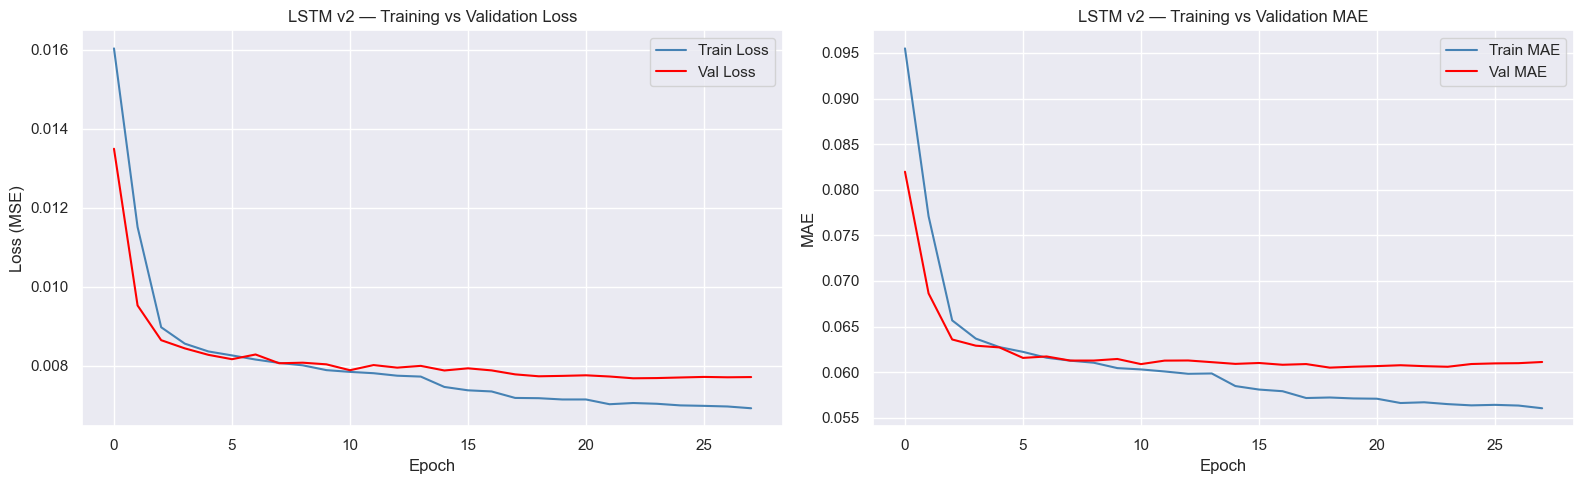

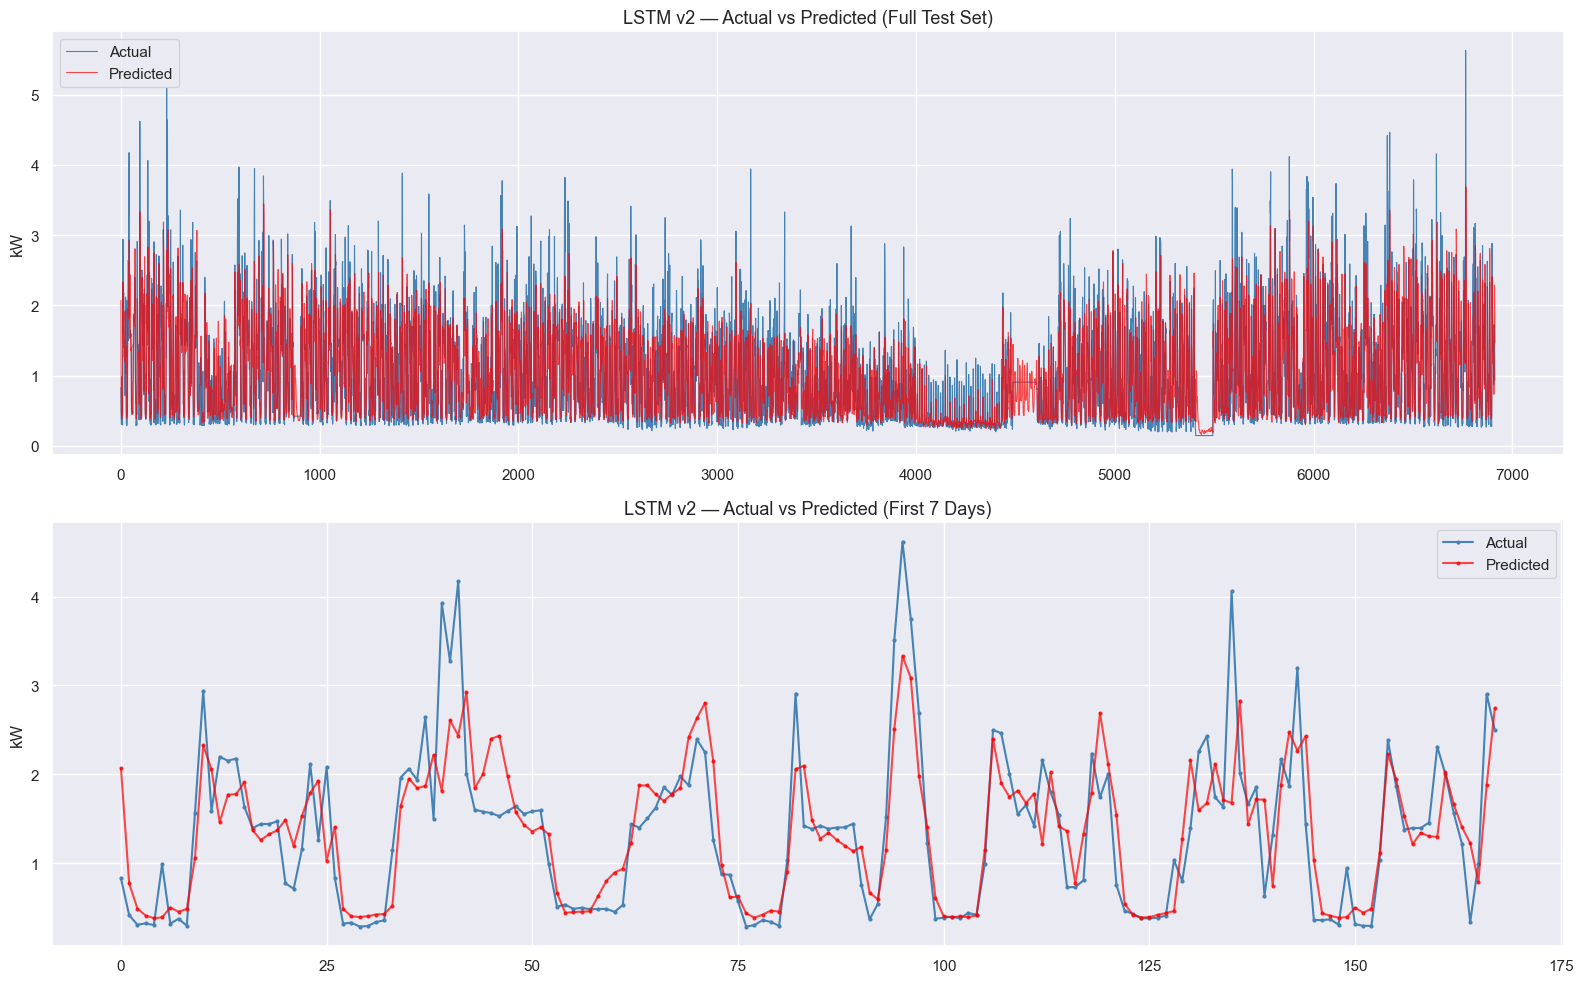

✅ LSTM model saved → models/lstm_model.keras
✅ Scaler saved     → models/scaler_multi.pkl
✅ N_features saved → models/n_features.pkl


In [13]:
import joblib
import os

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history_multi.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history_multi.history['val_loss'], label='Val Loss', color='red')
axes[0].set_title('LSTM v2 — Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()

axes[1].plot(history_multi.history['mae'], label='Train MAE', color='steelblue')
axes[1].plot(history_multi.history['val_mae'], label='Val MAE', color='red')
axes[1].set_title('LSTM v2 — Training vs Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/lstm_training_history.png', dpi=150)
plt.show()

# Plot predictions vs actual
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Full test set
axes[0].plot(y_test_multi, color='steelblue', linewidth=0.8, label='Actual')
axes[0].plot(y_pred_multi, color='red', linewidth=0.8, label='Predicted', alpha=0.7)
axes[0].set_title('LSTM v2 — Actual vs Predicted (Full Test Set)', fontsize=13)
axes[0].set_ylabel('kW')
axes[0].legend()

# First 7 days
axes[1].plot(y_test_multi[:168], color='steelblue', linewidth=1.5, 
             label='Actual', marker='o', markersize=2)
axes[1].plot(y_pred_multi[:168], color='red', linewidth=1.5, 
             label='Predicted', marker='o', markersize=2, alpha=0.7)
axes[1].set_title('LSTM v2 — Actual vs Predicted (First 7 Days)', fontsize=13)
axes[1].set_ylabel('kW')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/lstm_predictions.png', dpi=150)
plt.show()

# Save models
os.makedirs('../models', exist_ok=True)
model_multi.save('../models/lstm_model.keras')
joblib.dump(scaler_multi, '../models/scaler_multi.pkl')
joblib.dump(N_FEATURES, '../models/n_features.pkl')

print("✅ LSTM model saved → models/lstm_model.keras")
print("✅ Scaler saved     → models/scaler_multi.pkl")
print("✅ N_features saved → models/n_features.pkl")